In [1]:
import os, json, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.17.0
GPU: []


In [2]:
train_path = r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray\train"
val_path   = r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray\val"
test_path  = r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray\test"

DATA_DIR         = r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray"
AUG_DIR          = r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray_aug"
MODEL_PATH       = r"C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras"
INDICES_PATH     = r"C:\Users\Varalakshmi\Desktop\new_new_project\class_indices.json"

IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
EPOCHS_HEAD      = 15
EPOCHS_FINE      = 10
LR               = 1e-4
SEED             = 42
TARGET_PER_CLASS = 3000
CLASSES          = ['NORMAL', 'PNEUMONIA']

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
for split in ['train', 'val', 'test']:
    print(f'\n{split.upper()}:')
    for cls in CLASSES:
        path = Path(DATA_DIR) / split / cls
        count = len(list(path.glob('*.jpeg')) + list(path.glob('*.jpg')) + list(path.glob('*.png')))
        print(f'  {cls}: {count}')


TRAIN:
  NORMAL: 1341
  PNEUMONIA: 3875

VAL:
  NORMAL: 8
  PNEUMONIA: 8

TEST:
  NORMAL: 234
  PNEUMONIA: 390


In [4]:
aug_gen = ImageDataGenerator(
    rotation_range=12,
    zoom_range=0.12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    shear_range=5,
    fill_mode='nearest'
)

def get_images(folder):
    files = []
    for ext in ('*.jpeg', '*.jpg', '*.png'):
        files += list(Path(folder).glob(ext))
    return files

def augment_to_target(src_dir, dst_dir, target, cls_name):
    dst_path = Path(dst_dir)
    dst_path.mkdir(parents=True, exist_ok=True)
    orig_files = get_images(src_dir)
    print(f'  [{cls_name}] Originals: {len(orig_files)} -> Target: {target}')
    for f in orig_files:
        shutil.copy(f, dst_path / f.name)
    needed = target - len(orig_files)
    if needed <= 0:
        all_copied = list(dst_path.glob('*'))
        for f in random.sample(all_copied, len(all_copied) - target):
            f.unlink()
        print(f'  [{cls_name}] Sampled down to {target}')
        return
    generated = 0
    while generated < needed:
        src_file = random.choice(orig_files)
        img = load_img(src_file, target_size=IMG_SIZE)
        x = np.expand_dims(img_to_array(img), axis=0)
        for batch in aug_gen.flow(x, batch_size=1):
            save_img(str(dst_path / f'aug_{cls_name}_{generated:05d}.jpeg'), batch[0])
            generated += 1
            break
        if generated % 500 == 0:
            print(f'    Generated {generated}/{needed}...')
    print(f'  [{cls_name}] Done -> {len(list(dst_path.glob("*")))} images')

print('Building augmented training set...')
for cls in CLASSES:
    augment_to_target(Path(DATA_DIR)/'train'/cls, Path(AUG_DIR)/'train'/cls, TARGET_PER_CLASS, cls)

for split in ['val', 'test']:
    for cls in CLASSES:
        dst = Path(AUG_DIR) / split / cls
        if dst.exists(): shutil.rmtree(dst)
        shutil.copytree(Path(DATA_DIR) / split / cls, dst)

print('Done!')

Building augmented training set...
  [NORMAL] Originals: 1341 -> Target: 3000
    Generated 500/1659...
    Generated 1000/1659...
    Generated 1500/1659...
  [NORMAL] Done -> 3000 images
  [PNEUMONIA] Originals: 3875 -> Target: 3000
  [PNEUMONIA] Sampled down to 3000
Done!


In [5]:
for split in ['train', 'val', 'test']:
    total = 0
    print(f'\n{split.upper()}:')
    for cls in CLASSES:
        path = Path(AUG_DIR) / split / cls
        count = len(list(path.glob('*.jpeg')) + list(path.glob('*.jpg')) + list(path.glob('*.png')))
        print(f'  {cls}: {count}')
        total += count
    print(f'  TOTAL: {total}')


TRAIN:
  NORMAL: 3000
  PNEUMONIA: 3000
  TOTAL: 6000

VAL:
  NORMAL: 8
  PNEUMONIA: 8
  TOTAL: 16

TEST:
  NORMAL: 234
  PNEUMONIA: 390
  TOTAL: 624


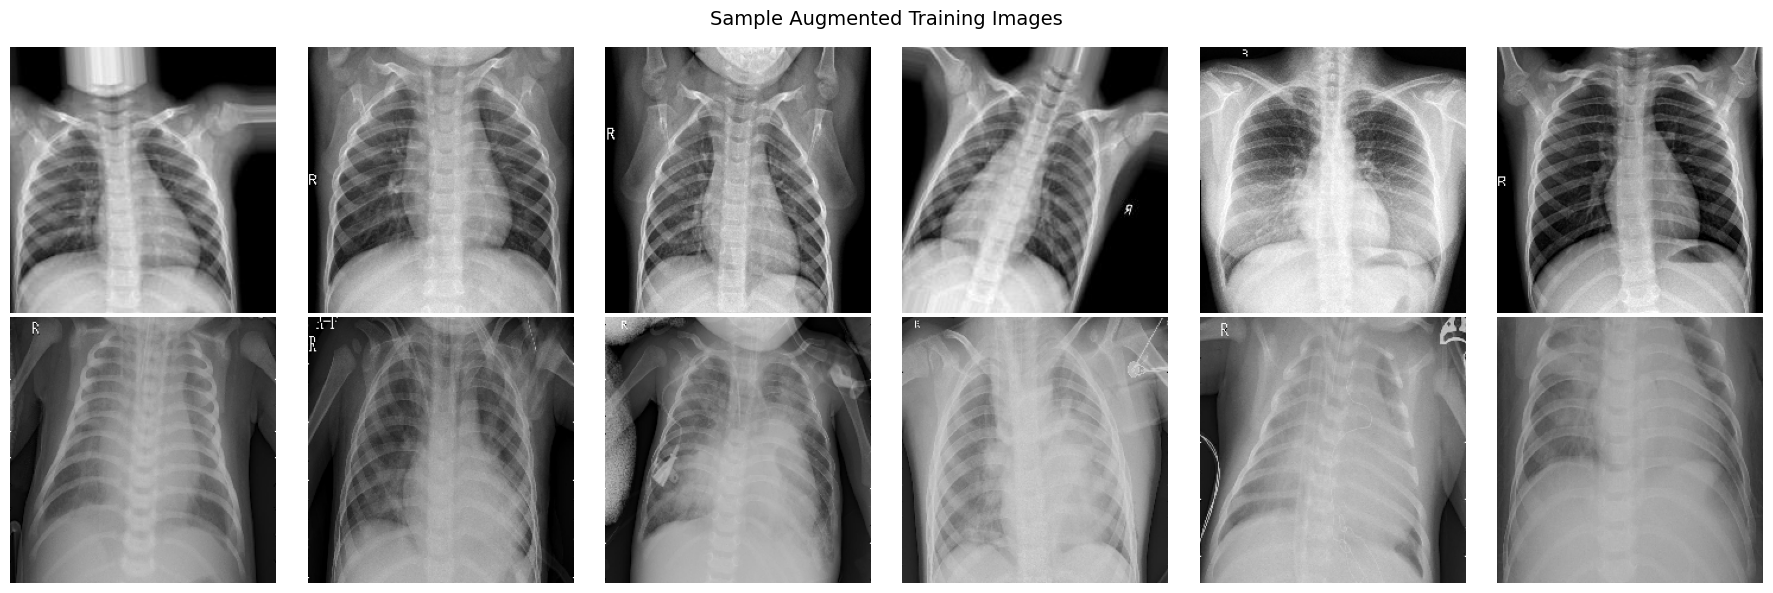

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row, cls in enumerate(CLASSES):
    for col, f in enumerate(random.sample(get_images(Path(AUG_DIR)/'train'/cls), 6)):
        axes[row, col].imshow(load_img(f, target_size=IMG_SIZE), cmap='gray')
        axes[row, col].axis('off')
        if col == 0: axes[row, col].set_ylabel(cls, fontsize=12, fontweight='bold')
plt.suptitle('Sample Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
train_datagen    = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.05)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{AUG_DIR}/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', seed=SEED)
val_gen = val_test_datagen.flow_from_directory(
    f'{AUG_DIR}/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', seed=SEED)
test_gen = val_test_datagen.flow_from_directory(
    f'{AUG_DIR}/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False, seed=SEED)

with open(INDICES_PATH, 'w') as f:
    json.dump(train_gen.class_indices, f)
print('Class indices:', train_gen.class_indices)

Found 6000 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
from tensorflow.keras import Input

base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,607,553 (9.95 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [17]:
def make_callbacks(phase):
    return [
        callbacks.EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1),
        callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True, mode='max', verbose=1),
        callbacks.CSVLogger(f'training_log_phase{phase}.csv')
    ]

In [18]:
total = TARGET_PER_CLASS * 2
weight_for_normal    = (1 / TARGET_PER_CLASS) * (total / 2.0)
weight_for_pneumonia = (1 / TARGET_PER_CLASS) * (total / 2.0)

class_weight = {
    0: weight_for_normal,
    1: weight_for_pneumonia
}

print("Class weights:", class_weight)
print("Class indices:", train_gen.class_indices)
history1 = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_HEAD, callbacks=make_callbacks(1))

Class weights: {0: 1.0, 1: 1.0}
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Epoch 1/15


C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.7989 - auc: 0.8723 - loss: 0.4256 - precision: 0.8301 - recall: 0.7447
Epoch 1: val_auc improved from -inf to 0.98438, saving model to C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 180s 902ms/step - accuracy: 0.7993 - auc: 0.8727 - loss: 0.4248 - precision: 0.8304 - recall: 0.7453 - val_accuracy: 0.6875 - val_auc: 0.9844 - val_loss: 0.5232 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.9440 - auc: 0.9879 - loss: 0.1416 - precision: 0.9504 - recall: 0.9372
Epoch 2: val_auc did not improve from 0.98438
188/188 ━━━━━━━━━━━━━━━━━━━━ 169s 881ms/step - accuracy: 0.9440 - auc: 0.9879 - loss: 0.1416 - precision: 0.9504 - recall: 0.9372 - val_accuracy: 0.7500 - val_auc: 0.9688 - val_loss: 0.4718 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
188/188 ━━━━━━━━━━━

In [19]:
model = tf.keras.models.load_model(MODEL_PATH)
print("Best model loaded from:", MODEL_PATH)

Best model loaded from: C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras


In [20]:
results = model.evaluate(test_gen, verbose=1)
for name, val in zip(['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall'], results):
    print(f'  {name:12s}: {val:.4f}')

y_pred_prob = model.predict(test_gen).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = test_gen.classes
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 611ms/step - accuracy: 0.7793 - auc: 0.6432 - loss: 0.6487 - precision: 0.4451 - recall: 0.6559
  Loss        : 0.3980
  Accuracy    : 0.8638
  AUC         : 0.9680
  Precision   : 0.8266
  Recall      : 0.9897
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 607ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.78       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.86       624



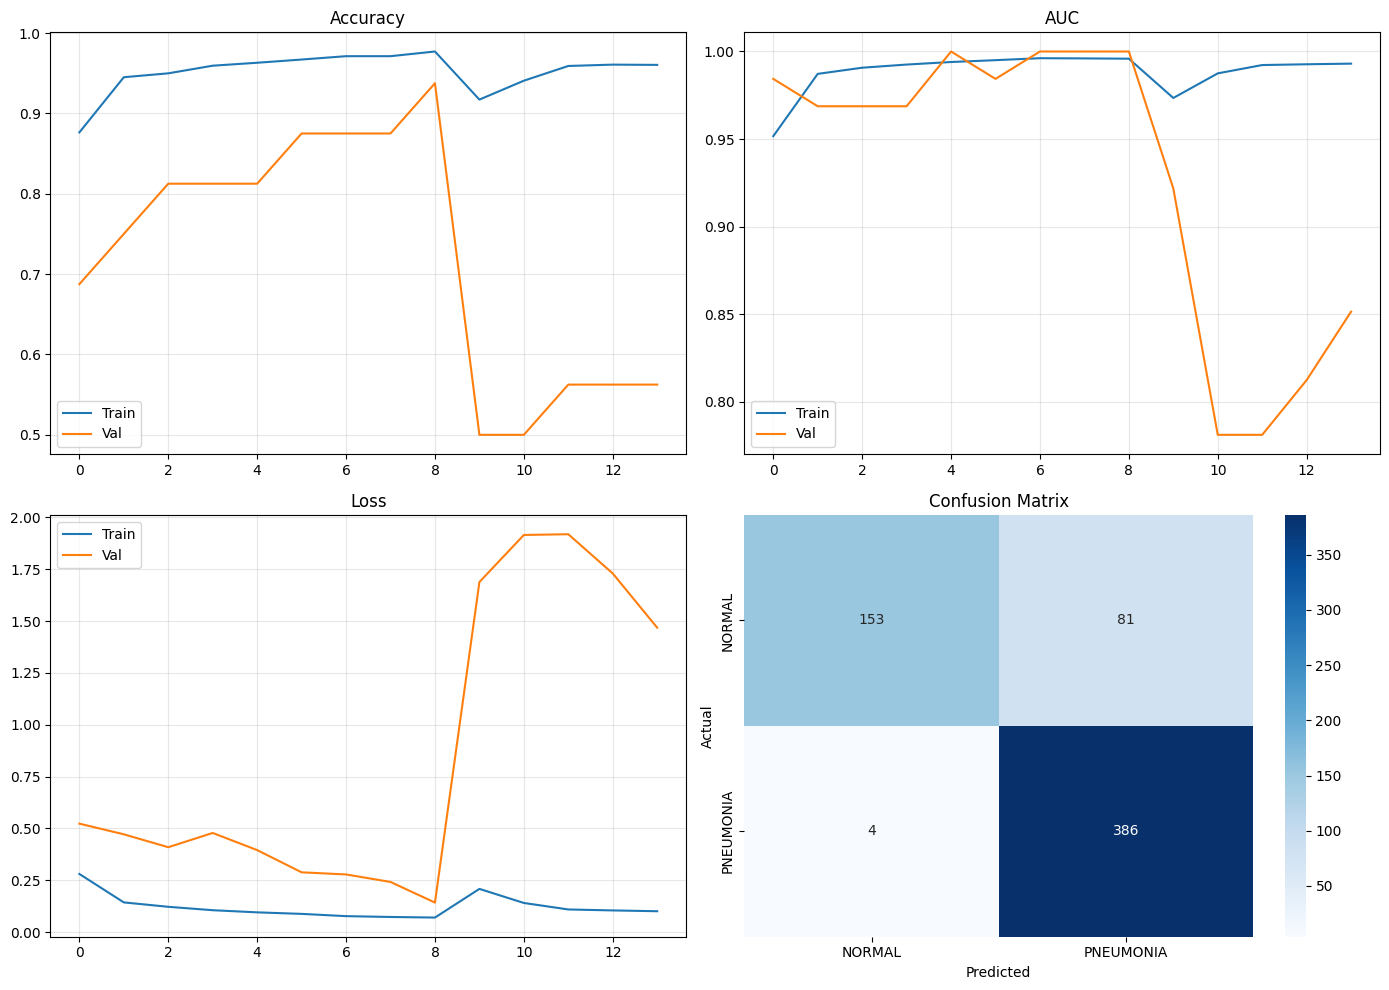

In [21]:
def join(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(join(history1, history2, 'accuracy'),     label='Train')
axes[0,0].plot(join(history1, history2, 'val_accuracy'), label='Val')
axes[0,0].set_title('Accuracy'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(join(history1, history2, 'auc'),     label='Train')
axes[0,1].plot(join(history1, history2, 'val_auc'), label='Val')
axes[0,1].set_title('AUC'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(join(history1, history2, 'loss'),     label='Train')
axes[1,0].plot(join(history1, history2, 'val_loss'), label='Val')
axes[1,0].set_title('Loss'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'], yticklabels=['NORMAL','PNEUMONIA'], ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix')
axes[1,1].set_ylabel('Actual'); axes[1,1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
for f in [MODEL_PATH, INDICES_PATH]:
    print(f'  {f}  ({os.path.getsize(f)/1024:.1f} KB)')

  C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras  (13472.0 KB)
  C:\Users\Varalakshmi\Desktop\new_new_project\class_indices.json  (0.0 KB)


In [23]:
import tensorflow as tf

model = tf.keras.models.load_model(r"C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras")

print("=== ALL LAYERS ===")
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

print("\n=== LAYERS INSIDE MOBILENETV2 ===")
for layer in model.layers:
    if hasattr(layer, 'layers'):
        for i, sublayer in enumerate(layer.layers):
            print(i, sublayer.name, type(sublayer).__name__)

=== ALL LAYERS ===
0 input_layer_4 InputLayer
1 mobilenetv2_1.00_224 Functional
2 global_average_pooling2d_2 GlobalAveragePooling2D
3 batch_normalization_2 BatchNormalization
4 dense_6 Dense
5 dropout_4 Dropout
6 dense_7 Dense
7 dropout_5 Dropout
8 dense_8 Dense

=== LAYERS INSIDE MOBILENETV2 ===
0 input_layer_3 InputLayer
1 Conv1 Conv2D
2 bn_Conv1 BatchNormalization
3 Conv1_relu ReLU
4 expanded_conv_depthwise DepthwiseConv2D
5 expanded_conv_depthwise_BN BatchNormalization
6 expanded_conv_depthwise_relu ReLU
7 expanded_conv_project Conv2D
8 expanded_conv_project_BN BatchNormalization
9 block_1_expand Conv2D
10 block_1_expand_BN BatchNormalization
11 block_1_expand_relu ReLU
12 block_1_pad ZeroPadding2D
13 block_1_depthwise DepthwiseConv2D
14 block_1_depthwise_BN BatchNormalization
15 block_1_depthwise_relu ReLU
16 block_1_project Conv2D
17 block_1_project_BN BatchNormalization
18 block_2_expand Conv2D
19 block_2_expand_BN BatchNormalization
20 block_2_expand_relu ReLU
21 block_2_depthw

In [24]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from pathlib import Path

model = tf.keras.models.load_model(r"C:\Users\Varalakshmi\Desktop\new_new_project\pneumonia_model.keras")

with open(r"C:\Users\Varalakshmi\Desktop\new_new_project\class_indices.json") as f:
    class_indices = json.load(f)

print("Class indices:", class_indices)

test_normal_dir    = Path(r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray\test\NORMAL")
test_pneumonia_dir = Path(r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\pneumonia dataset\chest_xray\test\PNEUMONIA")

def test_images(folder, true_label, n=5):
    files = list(folder.glob("*.jpeg"))[:n]
    print(f"\n--- {true_label} samples ---")
    for f in files:
        img = load_img(f, target_size=(224, 224))
        arr = np.expand_dims(img_to_array(img) / 255.0, axis=0).astype(np.float32)
        prob = float(model.predict(arr, verbose=0)[0][0])
        pred = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
        correct = "✓" if pred == true_label else "✗"
        print(f"  {correct} prob={prob:.3f} → predicted={pred} | true={true_label}")

test_images(test_normal_dir,    "NORMAL",    n=5)
test_images(test_pneumonia_dir, "PNEUMONIA", n=5)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}

--- NORMAL samples ---
  ✓ prob=0.043 → predicted=NORMAL | true=NORMAL
  ✓ prob=0.035 → predicted=NORMAL | true=NORMAL
  ✓ prob=0.020 → predicted=NORMAL | true=NORMAL
  ✗ prob=0.787 → predicted=PNEUMONIA | true=NORMAL
  ✓ prob=0.001 → predicted=NORMAL | true=NORMAL

--- PNEUMONIA samples ---
  ✓ prob=0.990 → predicted=PNEUMONIA | true=PNEUMONIA
  ✓ prob=0.945 → predicted=PNEUMONIA | true=PNEUMONIA
  ✓ prob=1.000 → predicted=PNEUMONIA | true=PNEUMONIA
  ✓ prob=1.000 → predicted=PNEUMONIA | true=PNEUMONIA
  ✓ prob=1.000 → predicted=PNEUMONIA | true=PNEUMONIA
